In [1]:
import pandas as pd

correct_hm_ru = pd.read_csv('annotation-correct-hm-ru.csv')

In [ ]:
def prepare_corr_datasets(df, feature):
    match feature:
        case 'upos':
            predict = df.filter(['upos','score'], axis=1)
            predict['upos'].fillna('0', inplace=True)
        case 'deprel':
            predict = df.filter(['deprel', 'score'], axis=1)
            predict['deprel'].fillna('0', inplace=True)
        case 'case':
            predict = df.filter(['case', 'score'], axis=1)
            predict['case'].fillna('0', inplace=True)
        case 'ner':
            predict = df.filter(['ner', 'score'], axis=1)
            predict['ner'].fillna('0', inplace=True)
        case 'gen':
            predict = df.filter(['gender', 'score'], axis=1)
            predict['gender'].fillna('0', inplace=True)
        case 'anim':
            predict = df.filter(['animacy', 'score'], axis=1)
            predict['animacy'].fillna('0', inplace=True)
        case 'num':
            predict = df.filter(['number', 'score'], axis=1)
            predict['number'].fillna('0', inplace=True)
        case _:
            raise ValueError('This feature does not exist.')
    return predict

In [7]:
upos_predict = prepare_corr_datasets(correct_hm_ru, 'upos')

### OLS Regression Analysis ###

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.formula.api as ols

upos_predict['upos'] = upos_predict['upos'].astype('category')

model = ols.ols("score ~ C(upos, Sum)", data=upos_predict).fit()

# Print the model summary
print(model.summary())

### Point-Biserial Coefficients ###

Point-Biserial Correlation Results:
            correlation       p-value
upos_ADP      -0.039798  2.956947e-04
upos_ADV      -0.021908  4.640576e-02
upos_CCONJ    -0.049260  7.450955e-06
upos_NUM      -0.023968  2.933648e-02
upos_PRON     -0.045774  3.142018e-05
upos_PROPN     0.053223  1.290030e-06
upos_PUNCT     0.090424  1.776769e-16
upos_SCONJ    -0.036157  1.010100e-03


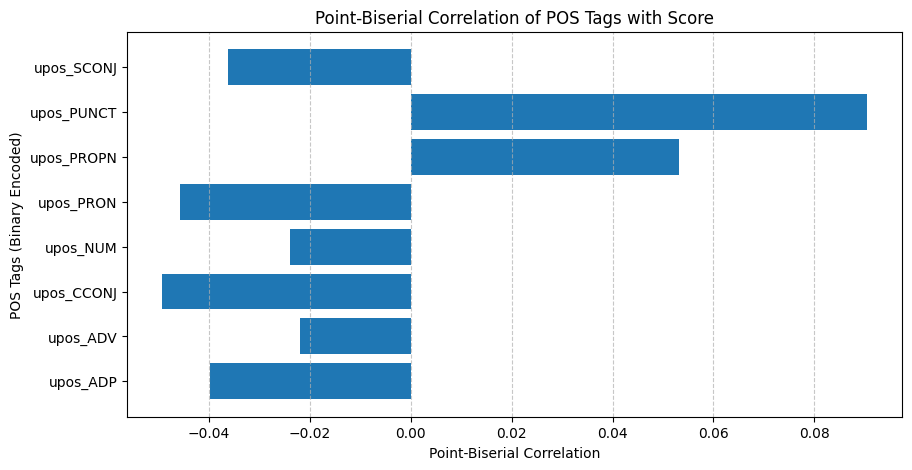

In [ ]:
import pandas as pd
from scipy.stats import pointbiserialr
import matplotlib.pyplot as plt

dummies = pd.get_dummies(upos_predict['upos'], prefix='upos')

correlation_results = {}

for col in dummies.columns:
    r_pb, p_value = pointbiserialr(dummies[col], upos_predict['score'])
    correlation_results[col] = {'correlation': r_pb, 'p-value': p_value}

correlation_df = pd.DataFrame.from_dict(correlation_results, orient='index')
correlation_df = correlation_df[correlation_df['p-value'] < 0.05]

# Display results
print("Point-Biserial Correlation Results:")
print(correlation_df)

# Plot correlation values
plt.figure(figsize=(10, 5))
plt.barh(correlation_df.index, correlation_df['correlation'])
plt.xlabel("Point-Biserial Correlation")
plt.ylabel("POS Tags (Binary Encoded)")
plt.title("Point-Biserial Correlation of POS Tags with Score")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()